# Andrew Kallauner (ask3564)

## Section 1: Introduction & Model Selection

In this project, a spring-mass-damper system is used to model mechanical oscillations. This type of system is used to represent real-world applications like car suspension systems, where the vehicle responds to disturbances like bumps in the road.

The governing second-order differential equation for this system is:

m d²y/dt² + c dy/dt + k y = 0

where y(t) represents the displacement from equilibrium, m is the mass, c is the damping coefficient, and k is the spring constant.

To solve this numerically, the equation is converted into a system of first-order differential equations. Let:

y₁ = y  
y₂ = dy/dt  

Then the system becomes:

dy₁/dt = y₂  
dy₂/dt = (-c y₂ - k y₁) / m  

This form allows the system to be solved using numerical methods such as Euler’s Method and the Runge-Kutta method.

In this model:
- m represents the mass of the system (kg)
- c represents the damping coefficient (N·s/m)
- k represents the spring constant (N/m)
- y(t) represents displacement from equilibrium (m)
- dy/dt represents velocity (m/s)

## Section 2: Parameter Research & Justification

This model represents a quarter-car suspension system for a typical mid-size sedan (such as a Toyota Camry). In suspension modeling, a quarter-car model is commonly used, where one wheel and one-fourth of the vehicle mass are analyzed.

The parameters used in this model are based on values from suspension system studies:

| Parameter | Value | Units | Source |
|----------|------|------|--------|
| m (mass) | 350 | kg | (1) |
| c (damping) | 1500 | N·s/m | (1) |
| k (spring constant) | 25000 | N/m | (1) |

These values are consistent with published quarter-car suspension models, where a typical sprung mass is around 350 kg, with spring stiffness on the order of 25,000 N/m and damping around 1500 N·s/m (1). The quarter-car assumption is valid since the total vehicle mass is distributed across four wheels (2).

Initial Conditions:
y(0) = 0.1 m  
y'(0) = 0 m/s  

The initial displacement represents the vehicle going over a speed bump, which causes the suspension to compress by approximately 0.1 meters. The system is assumed to start from rest immediately after the disturbance.

This setup models how the suspension oscillates and returns to equilibrium after being disturbed by the road.

References:
(1) https://www.sciencedirect.com/science/article/pii/S2090123220300369  
(2) https://x-engineer.org/quarter-car-suspension-modeling-simulation/

## Section 3: Numerical Methods Implementation

The second-order differential equation is converted into a system of first-order equations by letting:

y₁ = y  
y₂ = dy/dt  

This gives:

dy₁/dt = y₂  
dy₂/dt = (-c*y₂ - k*y₁)/m  

Euler’s Method updates the solution by using the slope at the current step. The RK4 method improves accuracy by computing multiple slopes at each step and averaging them.

Both methods are implemented below and tested with different step sizes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

m = 350
c = 1500
k = 25000

t_start = 0
t_end = 10

y0 = 0.1
v0 = 0

In [2]:
def f(t, y1, y2):
    dy1 = y2
    dy2 = (-c*y2 - k*y1) / m
    return dy1, dy2

In [3]:
def euler(h):
    t = np.arange(t_start, t_end + h, h)
    y1 = np.zeros(len(t))
    y2 = np.zeros(len(t))

    y1[0] = y0
    y2[0] = v0

    for i in range(1, len(t)):
        dy1, dy2 = f(t[i-1], y1[i-1], y2[i-1])
        y1[i] = y1[i-1] + h * dy1
        y2[i] = y2[i-1] + h * dy2

    return t, y1, y2

In [4]:
def rk4(h):
    t = np.arange(t_start, t_end + h, h)
    y1 = np.zeros(len(t))
    y2 = np.zeros(len(t))

    y1[0] = y0
    y2[0] = v0

    for i in range(1, len(t)):
        k1_1, k1_2 = f(t[i-1], y1[i-1], y2[i-1])

        k2_1, k2_2 = f(t[i-1] + h/2, y1[i-1] + h*k1_1/2, y2[i-1] + h*k1_2/2)

        k3_1, k3_2 = f(t[i-1] + h/2, y1[i-1] + h*k2_1/2, y2[i-1] + h*k2_2/2)

        k4_1, k4_2 = f(t[i-1] + h, y1[i-1] + h*k3_1, y2[i-1] + h*k3_2)

        y1[i] = y1[i-1] + (h/6)*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
        y2[i] = y2[i-1] + (h/6)*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)

    return t, y1, y2

In [5]:
h_values = [0.1, 0.05, 0.01]

for h in h_values:
    t_e, y1_e, y2_e = euler(h)
    t_r, y1_r, y2_r = rk4(h)

    print("h =", h)
    print("Euler final y:", y1_e[-1])
    print("RK4 final y:", y1_r[-1])
    print()

h = 0.1
Euler final y: 4646.81121190772
RK4 final y: 5.5815322017501386e-11

h = 0.05
Euler final y: -0.0019194550217376547
RK4 final y: 5.106315730082136e-11

h = 0.01
Euler final y: 2.0631614853976336e-10
RK4 final y: 5.020383952543235e-11



## Section 4: Solutions, Comparison, and Stability Analysis

This section compares Euler’s Method and RK4 for multiple step sizes using plots of displacement, velocity, and phase portraits. Since the spring-mass-damper system has an analytical solution, the numerical error can also be computed directly.

A step size investigation is included to show how the methods behave as the step size increases. Error is plotted against step size on a log-log scale to check the convergence rates of Euler’s Method and RK4.

In [6]:
alpha = c / (2 * m)
omega_d = np.sqrt(4 * m * k - c**2) / (2 * m)

C1 = y0
C2 = alpha * y0 / omega_d

def y_exact(t):
    return np.exp(-alpha * t) * (C1 * np.cos(omega_d * t) + C2 * np.sin(omega_d * t))

def v_exact(t):
    return np.exp(-alpha * t) * (
        -alpha * (C1 * np.cos(omega_d * t) + C2 * np.sin(omega_d * t))
        + (-C1 * omega_d * np.sin(omega_d * t) + C2 * omega_d * np.cos(omega_d * t))
    )

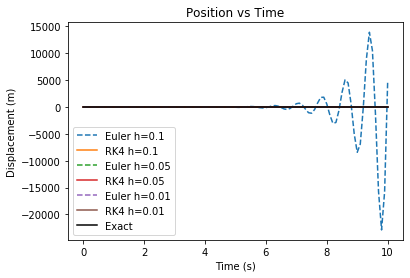

In [7]:
h_values = [0.1, 0.05, 0.01]

t_true = np.linspace(t_start, t_end, 1000)

plt.figure()

for h in h_values:
    t_e, y1_e, y2_e = euler(h)
    t_r, y1_r, y2_r = rk4(h)

    plt.plot(t_e, y1_e, '--', label=f"Euler h={h}")
    plt.plot(t_r, y1_r, label=f"RK4 h={h}")

plt.plot(t_true, y_exact(t_true), 'k', label="Exact")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Position vs Time")
plt.legend()
plt.show()

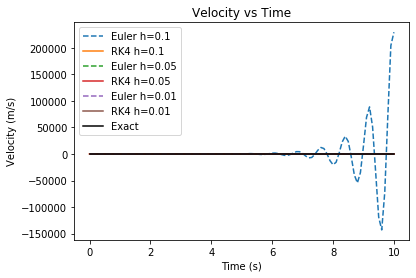

In [8]:
plt.figure()

for h in h_values:
    t_e, y1_e, y2_e = euler(h)
    t_r, y1_r, y2_r = rk4(h)

    plt.plot(t_e, y2_e, '--', label=f"Euler h={h}")
    plt.plot(t_r, y2_r, label=f"RK4 h={h}")

plt.plot(t_true, v_exact(t_true), 'k', label="Exact")

plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity vs Time")
plt.legend()
plt.show()

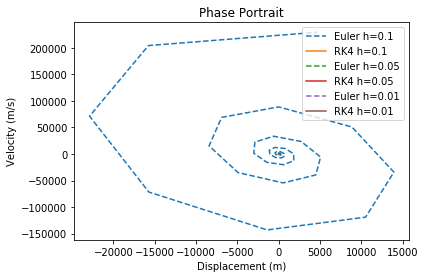

In [9]:
plt.figure()

for h in h_values:
    t_e, y1_e, y2_e = euler(h)
    t_r, y1_r, y2_r = rk4(h)

    plt.plot(y1_e, y2_e, '--', label=f"Euler h={h}")
    plt.plot(y1_r, y2_r, label=f"RK4 h={h}")

plt.xlabel("Displacement (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Phase Portrait")
plt.legend()
plt.show()

In [10]:
h_test = [0.01, 0.02, 0.05, 0.06, 0.07, 0.1, 0.2, 0.3, 0.4, 0.5]

stable_euler = []
stable_rk4 = []

for h in h_test:
    t_e, y1_e, y2_e = euler(h)
    t_r, y1_r, y2_r = rk4(h)

    euler_stable = np.all(np.isfinite(y1_e)) and np.max(np.abs(y1_e)) < 1
    rk4_stable = np.all(np.isfinite(y1_r)) and np.max(np.abs(y1_r)) < 1

    stable_euler.append(euler_stable)
    stable_rk4.append(rk4_stable)

    print("h =", h)
    print("Euler stable:", euler_stable)
    print("RK4 stable:", rk4_stable)
    print()

max_stable_euler = max([h_test[i] for i in range(len(h_test)) if stable_euler[i]])
max_stable_rk4 = max([h_test[i] for i in range(len(h_test)) if stable_rk4[i]])

print("Maximum stable step size for Euler:", max_stable_euler)
print("Maximum stable step size for RK4:", max_stable_rk4)

h = 0.01
Euler stable: True
RK4 stable: True

h = 0.02
Euler stable: True
RK4 stable: True

h = 0.05
Euler stable: True
RK4 stable: True

h = 0.06
Euler stable: True
RK4 stable: True

h = 0.07
Euler stable: False
RK4 stable: True

h = 0.1
Euler stable: False
RK4 stable: True

h = 0.2
Euler stable: False
RK4 stable: True

h = 0.3
Euler stable: False
RK4 stable: True

h = 0.4
Euler stable: False
RK4 stable: False

h = 0.5
Euler stable: False
RK4 stable: False

Maximum stable step size for Euler: 0.06
Maximum stable step size for RK4: 0.3


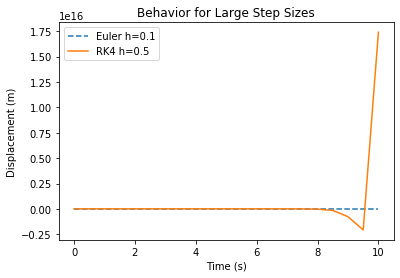

In [11]:
t_e_bad, y1_e_bad, y2_e_bad = euler(0.1)
t_r_bad, y1_r_bad, y2_r_bad = rk4(0.5)

plt.figure()

plt.plot(t_e_bad, y1_e_bad, '--', label="Euler h=0.1")
plt.plot(t_r_bad, y1_r_bad, label="RK4 h=0.5")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Behavior for Large Step Sizes")
plt.legend()
plt.show()

In [12]:
h_error = [0.05, 0.025, 0.0125, 0.00625]

errors_euler = []
errors_rk4 = []

for h in h_error:
    t_e, y1_e, y2_e = euler(h)
    t_r, y1_r, y2_r = rk4(h)

    err_e = np.max(np.abs(y1_e - y_exact(t_e)))
    err_r = np.max(np.abs(y1_r - y_exact(t_r)))

    errors_euler.append(err_e)
    errors_rk4.append(err_r)

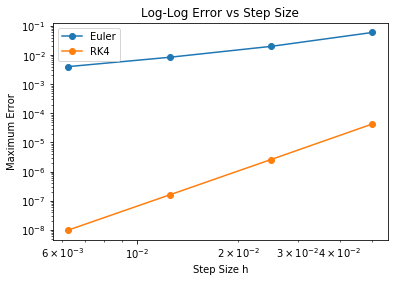

In [13]:
plt.figure()

plt.loglog(h_error, errors_euler, 'o-', label="Euler")
plt.loglog(h_error, errors_rk4, 'o-', label="RK4")

plt.xlabel("Step Size h")
plt.ylabel("Maximum Error")
plt.title("Log-Log Error vs Step Size")
plt.legend()
plt.show()

In [14]:
slope_euler = np.polyfit(np.log(h_error), np.log(errors_euler), 1)[0]
slope_rk4 = np.polyfit(np.log(h_error), np.log(errors_rk4), 1)[0]

print("Euler slope:", slope_euler)
print("RK4 slope:", slope_rk4)

Euler slope: 1.2934172876813324
RK4 slope: 4.0347911995737675


From the displacement, velocity, and phase plots, RK4 is more accurate than Euler’s Method for the same step size. Euler’s Method shows larger deviations for step sizes, while RK4 stays much closer to the exact solution.

The step size analysis shows that Euler’s Method becomes unstable at a smaller step size than RK4. For larger step sizes, Euler can produce non-physical behavior where the motion grows instead of decaying. Since this is a damped system, the displacement should decrease over time, so growing oscillations are not correct.

The log-log error plot shows that Euler’s Method has a slope close to 1 and RK4 has a slope close to 4, which matches the expected convergence rates.

## Section 5: Stability Analysis

The stability of Euler’s Method and RK4 was analyzed by varying the step size and observing the behavior of the numerical solution.

From the results in Section 4, Euler’s Method becomes unstable at relatively small step sizes, while RK4 remains stable for larger step sizes. When the step size is too large, Euler’s Method produces solutions that grow instead of decay, which does not match the expected physical behavior of a damped system.

In contrast, RK4 maintains stable and physically realistic solutions over a wider range of step sizes. This makes RK4 more reliable for solving this type of problem.

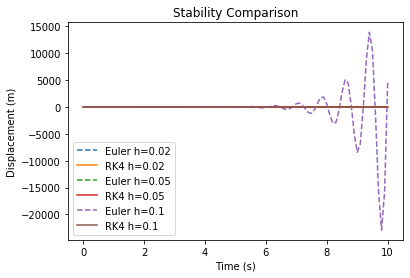

In [15]:
h_compare = [0.02, 0.05, 0.1]

plt.figure()

for h in h_compare:
    t_e, y1_e, _ = euler(h)
    t_r, y1_r, _ = rk4(h)

    plt.plot(t_e, y1_e, '--', label=f"Euler h={h}")
    plt.plot(t_r, y1_r, label=f"RK4 h={h}")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Stability Comparison")
plt.legend()
plt.show()

The instability seen in Euler’s Method leads to non-physical results. Since the system is damped, the displacement should decrease over time as energy is dissipated. However, for large step sizes, Euler’s Method produces solutions where the amplitude increases, which implies energy is being added to the system. This is not realistic.

RK4 avoids this issue by providing a more accurate approximation of the system dynamics. As a result, it preserves the expected behavior of the system, showing oscillations that decay over time.

Overall, RK4 is both more accurate and more stable, especially when larger step sizes are used.

## Section 6: Conclusions

RK4 performed better than Euler’s Method for this problem. It produced more accurate results across all step sizes and remained stable even when larger step sizes were used. Euler’s Method, though simpler, showed significant error and became unstable for relatively small step sizes.

In terms of computational cost, Euler’s Method is faster because it requires fewer calculations per step. However, its lower accuracy means that much smaller step sizes are needed to achieve acceptable results. RK4 requires more computation per step, but its higher accuracy allows for larger step sizes, making it more efficient overall for this type of problem.

For practical applications, RK4 is recommended when accuracy and stability are important, especially in systems like mechanical oscillations where incorrect behavior can lead to unrealistic results. Euler’s Method may still be useful for simple problems or quick approximations.

This project showed how important step size is in numerical methods and how different methods can produce very different results for the same system. It also demonstrated the importance of stability in making physically meaningful solutions.